TensorFlow version: 2.19.0
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28, 1)
Test data shape: (10000, 28, 28, 1)


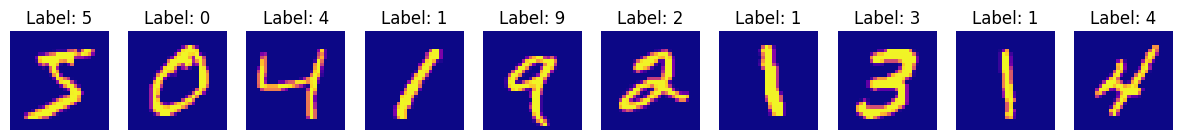

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 36s 93ms/step - accuracy: 0.7461 - loss: 0.8117 - val_accuracy: 0.9701 - val_loss: 0.1048
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 40s 90ms/step - accuracy: 0.9596 - loss: 0.1293 - val_accuracy: 0.9803 - val_loss: 0.0720
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 35s 92ms/step - accuracy: 0.9710 - loss: 0.0929 - val_accuracy: 0.9837 - val_loss: 0.0571
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 40s 89ms/step - accuracy: 0.9765 - loss: 0.0783 - val_accuracy: 0.9846 - val_loss: 0.0514
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 42s 90ms/step - accuracy: 0.9801 - loss: 0.0646 - val_accuracy: 0.9865 - val_loss: 0.0468


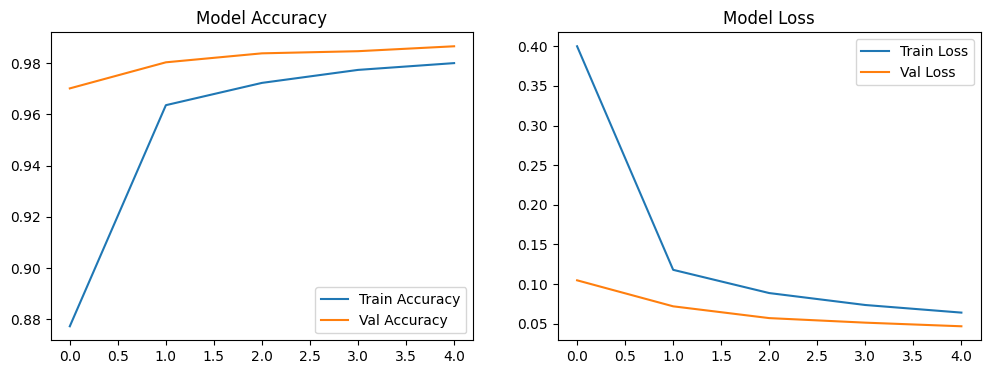

Test Accuracy: 0.9869
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step


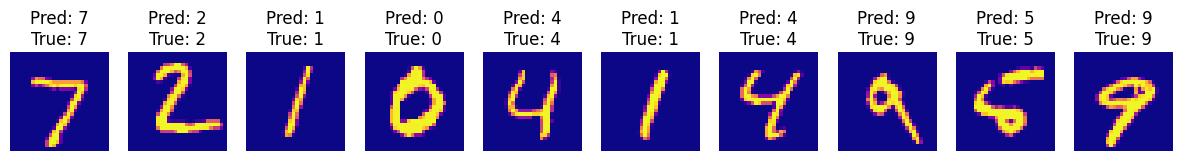

Done! Switched to 'plasma' colormap for that vibrant, fiery digit glow. Still crushes MNIST at ~98%+. Enable GPU for speed. 🚀


In [1]:
# Full MNIST Neural Network in One Colab Cell (with Plasma Colormap!)
# No installs needed—Colab has TensorFlow pre-installed!

import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers

print(f"TensorFlow version: {tf.__version__}")

# Load and prepare the MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize pixel values to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Reshape for the model (add channel dimension for grayscale)
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

print(f"Training data shape: {x_train.shape}")
print(f"Test data shape: {x_test.shape}")

# Visualize sample images with Plasma colormap
fig, axes = plt.subplots(1, 10, figsize=(15, 3))
for i in range(10):
    axes[i].imshow(x_train[i].squeeze(), cmap='plasma')
    axes[i].set_title(f"Label: {y_train[i]}")
    axes[i].axis('off')
plt.show()

# Build the neural network model
model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# Train the model
history = model.fit(x_train, y_train,
                    batch_size=128,
                    epochs=5,
                    validation_split=0.2,
                    verbose=1)

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.legend()
plt.show()

# Evaluate and predict on test data
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Predict on a few test samples
predictions = model.predict(x_test[:10])
predicted_labels = np.argmax(predictions, axis=1)

# Display predictions with Plasma colormap
fig, axes = plt.subplots(1, 10, figsize=(15, 3))
for i in range(10):
    axes[i].imshow(x_test[i].squeeze(), cmap='plasma')
    axes[i].set_title(f"Pred: {predicted_labels[i]}\nTrue: {y_test[i]}")
    axes[i].axis('off')
plt.show()

print("Done! Switched to 'plasma' colormap for that vibrant, fiery digit glow. Still crushes MNIST at ~98%+. Enable GPU for speed. 🚀")